# The Vehicle Library

`VehicleLibrary` is a repository of standard bridge design vehicles, **grouped by region**. Each getter returns a `Vehicle` (a set of axle point loads) ready for a `BridgeAnalysis`:

```python
cba.VehicleLibrary.AU.get_m1600(6.25)    # AS 5100.2 road
cba.VehicleLibrary.US.get_hl93_truck()     # AASHTO LRFD
cba.VehicleLibrary.EU.get_lm71()           # Eurocode rail
```

The regions are `AU` (AS 5100.2 / NAASRA), `US` (AASHTO / AREA Cooper), `EU` (Eurocode EN 1991-2), `UK` (BS 5400 / CS 454), `CA` (CSA S6) and `CN` (JTG D60).

Where a code pairs the vehicle with a **lane (distributed) load**, that intensity is noted in the getter's docstring and applied through `BridgeAnalysis.run_load_model(..., w_lane=)` (see the last section).

Use `cba.plot_vehicle(vehicle)` (or `vehicle.plot()`) to sketch a vehicle's axle loads.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycba as cba
VL = cba.VehicleLibrary


## Australia — AS 5100.2 and the historical NAASRA models

`VL.AU` carries the current AS 5100.2 models (M1600, S1600, A160, W80, 300LA / LA rail) and the historical NAASRA road trucks (T44, MS18), plus the ABAG assessment vehicles.

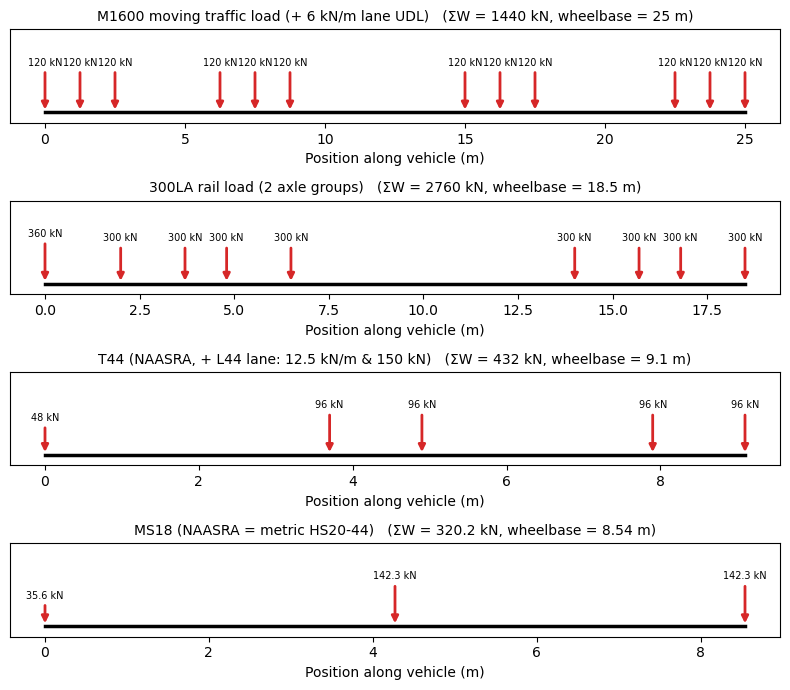

In [2]:
fig, axs = plt.subplots(4, 1, figsize=(8, 7))
cba.plot_vehicle(VL.AU.get_m1600(6.25), ax=axs[0], title="M1600 moving traffic load (+ 6 kN/m lane UDL)")
cba.plot_vehicle(VL.AU.get_300la(axle_group_count=2), ax=axs[1], title="300LA rail load (2 axle groups)")
cba.plot_vehicle(VL.AU.get_t44(), ax=axs[2], title="T44 (NAASRA, + L44 lane: 12.5 kN/m & 150 kN)")
cba.plot_vehicle(VL.AU.get_ms18(), ax=axs[3], title="MS18 (NAASRA = metric HS20-44)")
fig.tight_layout()

## United States — AASHTO LRFD and the AREA Cooper rail series

`VL.US` carries the HL-93 design truck and tandem, and the Cooper E-series rail load (two locomotives, scaled by the E-number).

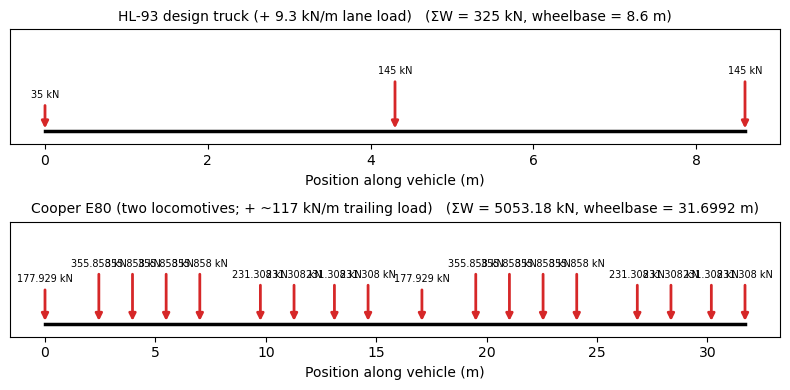

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4))
cba.plot_vehicle(VL.US.get_hl93_truck(), ax=axs[0], title="HL-93 design truck (+ 9.3 kN/m lane load)")
cba.plot_vehicle(VL.US.get_cooper(80), ax=axs[1], title="Cooper E80 (two locomotives; + ~117 kN/m trailing load)")
fig.tight_layout()

## Europe — Eurocode EN 1991-2

`VL.EU` carries the Load Model 1 tandem system (road) and rail Load Model 71.

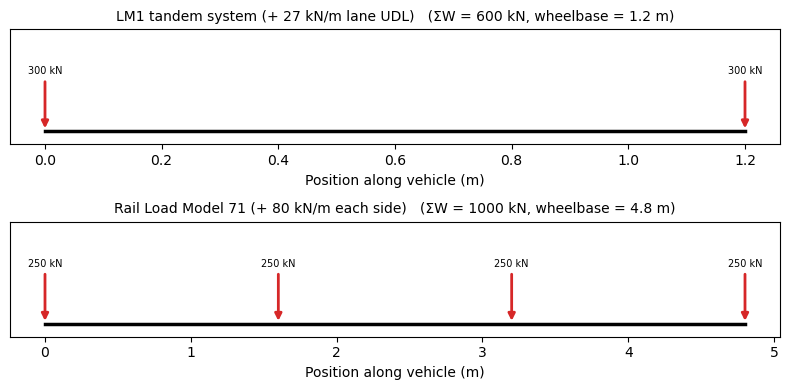

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(8, 4))
cba.plot_vehicle(VL.EU.get_lm1(), ax=axs[0], title="LM1 tandem system (+ 27 kN/m lane UDL)")
cba.plot_vehicle(VL.EU.get_lm71(), ax=axs[1], title="Rail Load Model 71 (+ 80 kN/m each side)")
fig.tight_layout()

## UK, Canada and China

`VL.UK` (BS 5400 / CS 454 HB), `VL.CA` (CSA S6 CL-625) and `VL.CN` (JTG D60 standard vehicle).

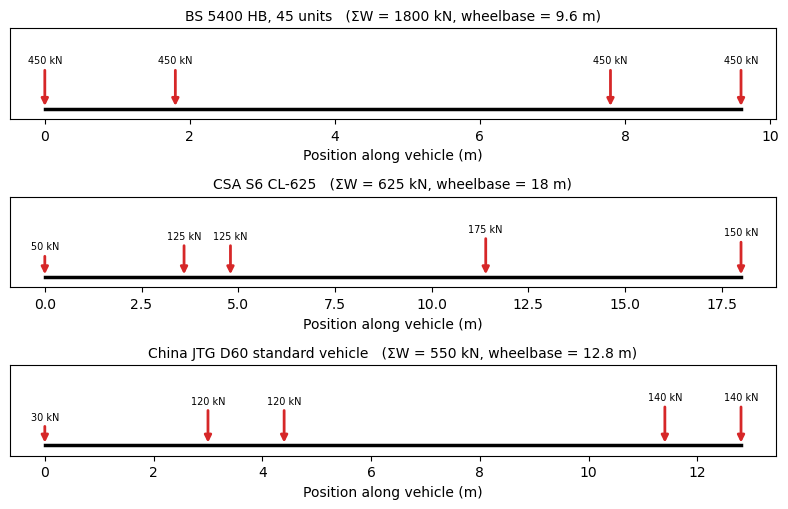

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(8, 5.2))
cba.plot_vehicle(VL.UK.get_hb(units=45), ax=axs[0], title="BS 5400 HB, 45 units")
cba.plot_vehicle(VL.CA.get_cl625(), ax=axs[1], title="CSA S6 CL-625")
cba.plot_vehicle(VL.CN.get_jtg_vehicle(), ax=axs[2], title="China JTG D60 standard vehicle")
fig.tight_layout()

## Using a model in an analysis

Pass a vehicle to `BridgeAnalysis`. For a code model that pairs the truck with a lane load, use `run_load_model(step, w_lane=...)` — here the HL-93 truck with its 9.3 kN/m design lane load over a two-span continuous bridge, enveloped over the traverse.

max sagging moment   =   1259.0 kN.m
max hogging moment   =  -1036.5 kN.m


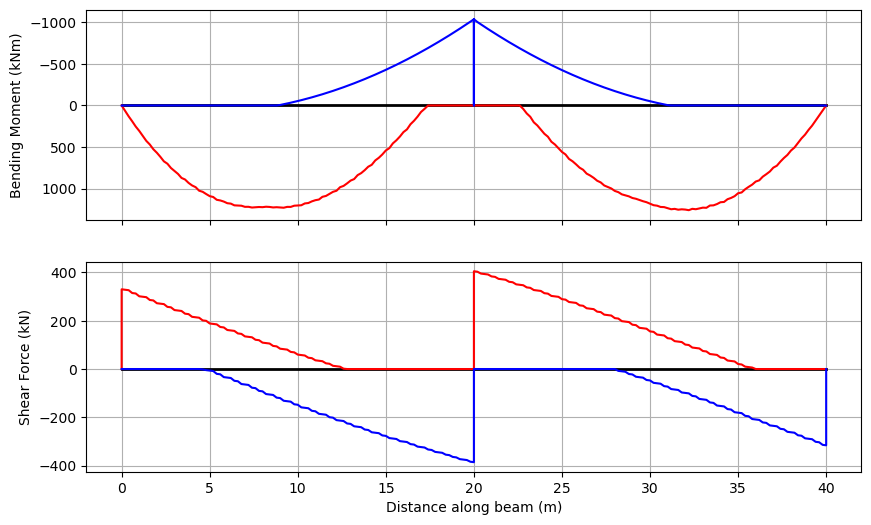

In [6]:
ba = cba.BeamAnalysis([20.0, 20.0], 1.0e7, [-1, 0, -1, 0, -1, 0])  # EI in kN.m^2
bridge = cba.BridgeAnalysis(ba, VL.US.get_hl93_truck())
env = bridge.run_load_model(step=0.5, w_lane=9.3)   # HL-93 truck + design lane load
env.plot()
print(f"max sagging moment   = {env.Mmax.max():8.1f} kN.m")
print(f"max hogging moment   = {env.Mmin.min():8.1f} kN.m")

## Companion lane loads (summary)

Several models are defined as a vehicle **plus** an accompanying lane/distributed load; pass it as `run_load_model(..., w_lane=)`:

| Model | `w_lane` (kN/m) | Note |
|-------|-----------------|------|
| `AU.get_m1600` | 6 | continuous under the truck |
| `AU.get_s1600` | 24 | stationary load |
| `AU.get_t44` | 12.5 | L44, also a 150 kN concentrated load |
| `US.get_hl93_truck` / `get_hl93_tandem` | 9.3 | design lane load |
| `US.get_cooper` | ≈ 1.46·E | trailing uniform load |
| `EU.get_lm1` | 27 | Lane 1 UDL (9 kN/m² × 3 m) |
| `EU.get_lm71` | 80 | each side, beyond the axles |
| `CA.get_cl625` | 9 | with 80%-reduced axles |

For models with a variable axle spacing (`get_hl93_truck`, `get_t44`, `get_ms18`, `get_hb`, `get_m1600`/`get_s1600`), pass the spacing that produces the worst effect.